In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aryashah2k/indian-medicinal-leaves-dataset/Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Nooni/2863.jpg
/kaggle/input/datasets/aryashah2k/indian-medicinal-leaves-dataset/Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Nooni/187.jpg
/kaggle/input/datasets/aryashah2k/indian-medicinal-leaves-dataset/Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Nooni/2844.jpg
/kaggle/input/datasets/aryashah2k/indian-medicinal-leaves-dataset/Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Nooni/708.jpg
/kaggle/input/datasets/aryashah2k/indian-medicinal-leaves-dataset/Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Nooni/2866.jpg
/kaggle/input/datasets/aryashah2k/indian-medicinal-leaves-dataset/Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Nooni/185.jpg
/kaggle/input/datasets/aryashah2k/indian-medicinal-leaves-dataset/Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Nooni/703.

In [2]:
import numpy as np 
import pandas as pd 
import os

In [5]:
def create_dataframe_from_folder(root_path):
    image_paths = []
    labels = []
    
    for label in os.listdir(root_path):
        class_path = os.path.join(root_path, label)
        
        if os.path.isdir(class_path):
            for img in os.listdir(class_path):
                img_path = os.path.join(class_path, img)
                
                if img.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp')):
                    image_paths.append(img_path)
                    labels.append(label)
    
    df = pd.DataFrame({
        'image_path': image_paths,
        'label': labels
    })
    
    return df


path_leaf = "/kaggle/input/datasets/aryashah2k/indian-medicinal-leaves-dataset/Indian Medicinal Leaves Image Datasets/Medicinal Leaf dataset"
path_plant = "/kaggle/input/datasets/aryashah2k/indian-medicinal-leaves-dataset/Indian Medicinal Leaves Image Datasets/Medicinal plant dataset"


df1 = create_dataframe_from_folder(path_leaf)
df  = create_dataframe_from_folder(path_plant)

In [6]:
df

,image_path,label
0,/kaggle/input/datasets/aryashah2k/indian-medic...,Nooni
1,/kaggle/input/datasets/aryashah2k/indian-medic...,Nooni
2,/kaggle/input/datasets/aryashah2k/indian-medic...,Nooni
3,/kaggle/input/datasets/aryashah2k/indian-medic...,Nooni
4,/kaggle/input/datasets/aryashah2k/indian-medic...,Nooni
...,...,...
5940,/kaggle/input/datasets/aryashah2k/indian-medic...,Ganike
5941,/kaggle/input/datasets/aryashah2k/indian-medic...,Ganike
5942,/kaggle/input/datasets/aryashah2k/indian-medic...,Ganike
5943,/kaggle/input/datasets/aryashah2k/indian-medic...,Ganike


In [8]:
df1

,image_path,label
0,/kaggle/input/datasets/aryashah2k/indian-medic...,Tecoma
1,/kaggle/input/datasets/aryashah2k/indian-medic...,Tecoma
2,/kaggle/input/datasets/aryashah2k/indian-medic...,Tecoma
3,/kaggle/input/datasets/aryashah2k/indian-medic...,Tecoma
4,/kaggle/input/datasets/aryashah2k/indian-medic...,Tecoma
...,...,...
6895,/kaggle/input/datasets/aryashah2k/indian-medic...,Seethaashoka
6896,/kaggle/input/datasets/aryashah2k/indian-medic...,Seethaashoka
6897,/kaggle/input/datasets/aryashah2k/indian-medic...,Seethaashoka
6898,/kaggle/input/datasets/aryashah2k/indian-medic...,Seethaashoka


In [9]:
df.shape


(5945, 2)

In [10]:
df.columns


Index(['image_path', 'label'], dtype='object')

In [11]:

df.duplicated().sum()

np.int64(0)

In [12]:
df.isnull().sum()

image_path    0
label         0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5945 entries, 0 to 5944
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  5945 non-null   object
 1   label       5945 non-null   object
dtypes: object(2)
memory usage: 93.0+ KB


In [14]:
df['label'].unique()

array(['Nooni', 'Nithyapushpa', 'Basale', 'Pomegranate', 'Honge',
       'Lemon_grass', 'Mint', 'Betel_Nut', 'Nagadali', 'Curry_Leaf',
       'Jasmine', 'Castor', 'Sapota', 'Neem', 'Ashoka', 'Brahmi',
       'Amruta_Balli', 'Pappaya', 'Pepper', 'Wood_sorel', 'Gauva',
       'Hibiscus', 'Ashwagandha', 'Aloevera', 'Raktachandini', 'Insulin',
       'Bamboo', 'Amla', 'Arali', 'Geranium', 'Avacado', 'Lemon', 'Ekka',
       'Betel', 'Henna', 'Doddapatre', 'Rose', 'Mango', 'Tulasi',
       'Ganike'], dtype=object)

In [15]:
df['label'].value_counts()

label
Jasmine          187
Rose             168
Hibiscus         165
Aloevera         164
Castor           160
Mint             153
Nagadali         152
Betel            151
Henna            150
Betel_Nut        146
Honge            146
Lemon_grass      146
Nithyapushpa     146
Basale           146
Nooni            146
Pomegranate      146
Brahmi           146
Ashoka           146
Amruta_Balli     146
Pappaya          146
Wood_sorel       146
Neem             146
Sapota           146
Curry_Leaf       146
Ashwagandha      146
Gauva            146
Pepper           146
Raktachandini    146
Arali            146
Insulin          146
Bamboo           146
Amla             146
Lemon            146
Avacado          146
Geranium         146
Ekka             146
Doddapatre       146
Mango            146
Tulasi           146
Ganike           115
Name: count, dtype: int64

In [16]:
import warnings
warnings.filterwarnings('ignore')

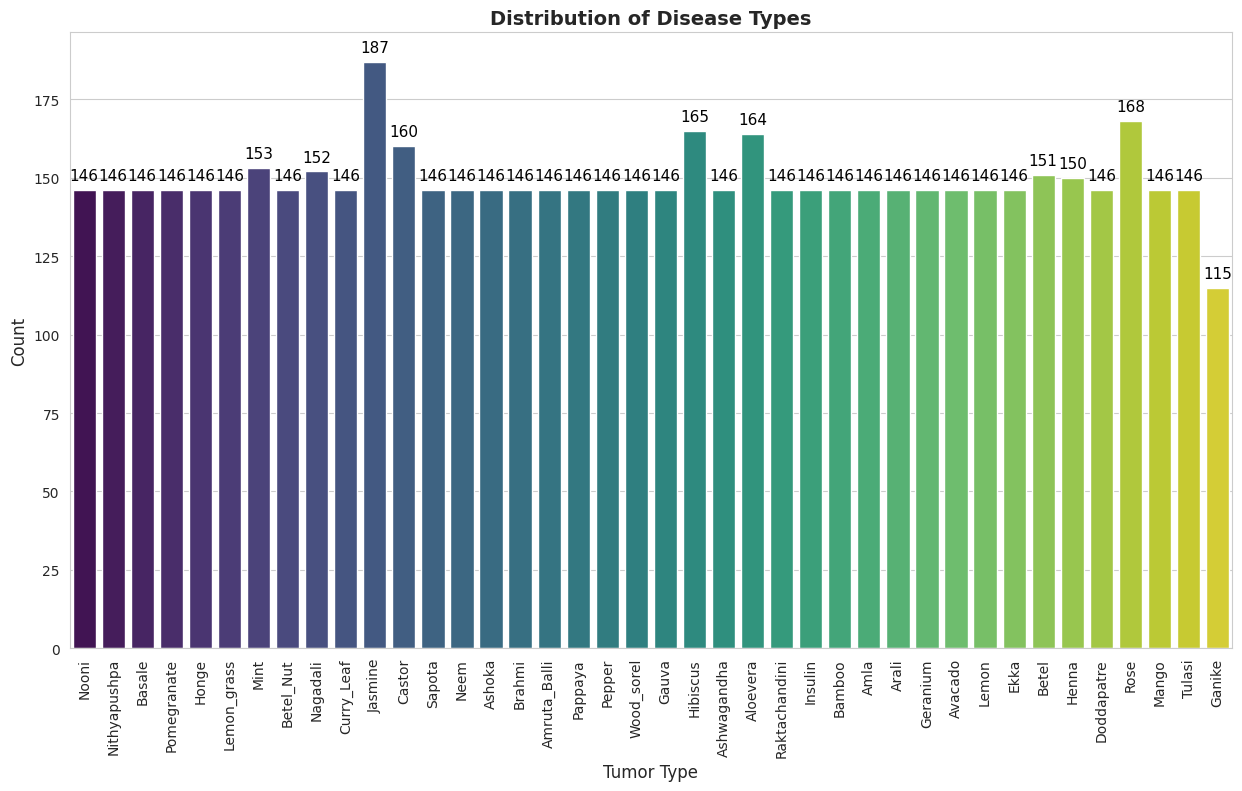

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(15, 8))
sns.countplot(data=df, x="label", palette="viridis", ax=ax)

ax.set_title("Distribution of Disease Types", fontsize=14, fontweight='bold')
ax.set_xlabel("Tumor Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.xticks(rotation = 90)
plt.show()


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

In [20]:
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

max_samples = train_df['label'].value_counts().max()

balanced_train_df = train_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(n=max_samples, replace=True, random_state=42)
).reset_index(drop=True)

balanced_train_df = balanced_train_df[['image_path', 'label']]

In [21]:
!pip install pyswarms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.1 MB/s eta 0:00:00


Using Medicinal plant dataset (40 classes)
Number of classes: 40
Using device: cuda

══════════════════════════════════════════════════════════════════════
Training Standard DenseNet121   (with tqdm progress)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 157MB/s]
Epoch 1/5 [Train]: 100%|██████████| 249/249 [00:58<00:00,  4.22batch/s, loss=0.8815, acc=79.23%]


Epoch  1   Train Loss 0.8815 | Acc 79.23%   |   Val Loss 0.3631 | Acc 88.90%


Epoch 2/5 [Train]: 100%|██████████| 249/249 [00:59<00:00,  4.16batch/s, loss=0.1924, acc=95.45%]


Epoch  2   Train Loss 0.1924 | Acc 95.45%   |   Val Loss 0.1713 | Acc 96.05%


...

Epoch  3   Train Loss 0.1410 | Acc 96.26%   |   Val Loss 0.2128 | Acc 94.11%


Epoch 4/5 [Train]: 100%|██████████| 249/249 [01:00<00:00,  4.13batch/s, loss=0.0970, acc=97.43%]


Epoch  4   Train Loss 0.0970 | Acc 97.43%   |   Val Loss 0.1687 | Acc 95.12%


Epoch 5/5 [Train]: 100%|██████████| 249/249 [01:00<00:00,  4.15batch/s, loss=0.0724, acc=98.09%]


Epoch  5   Train Loss 0.0724 | Acc 98.09%   |   Val Loss 0.1553 | Acc 95.54%


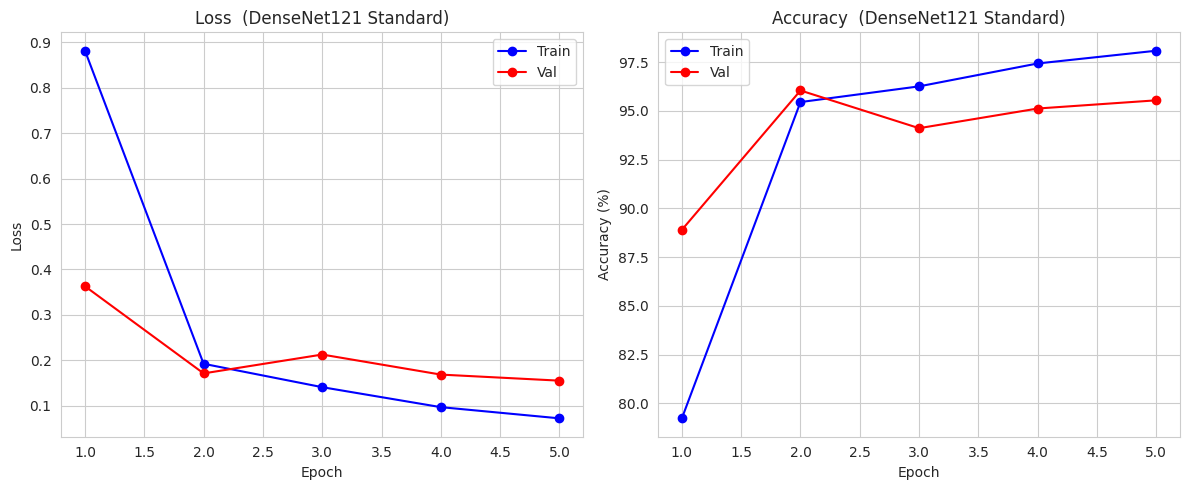

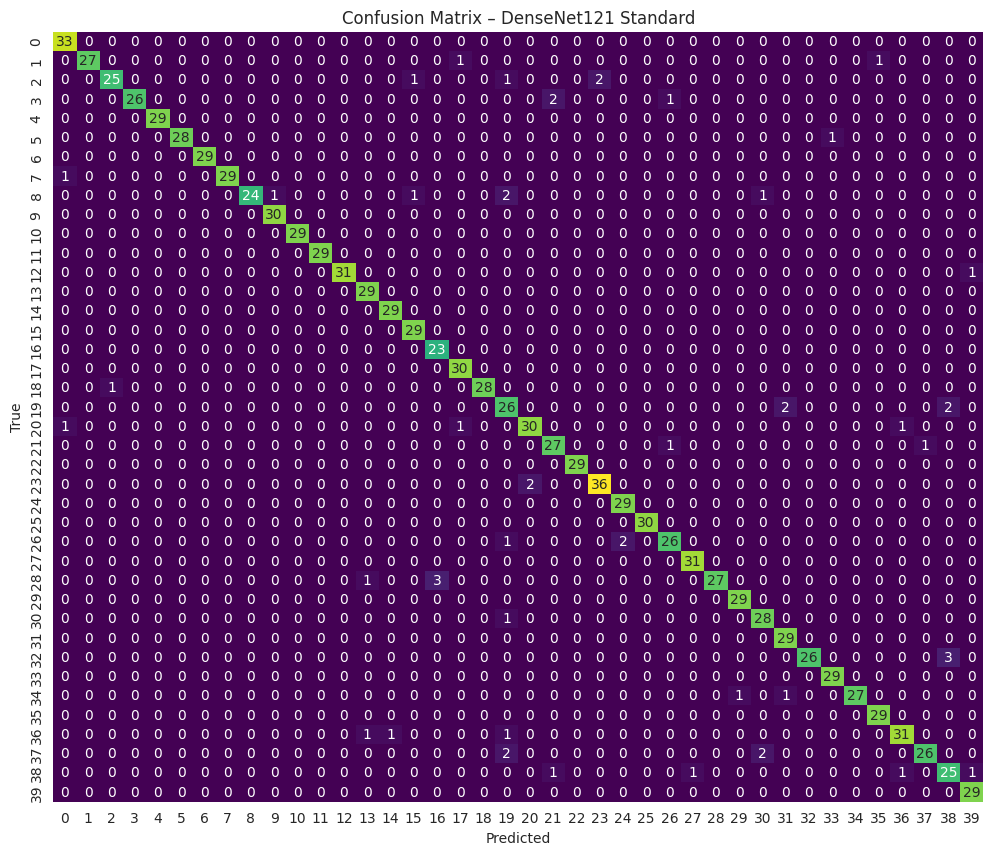

2026-04-03 11:55:23,124 - pyswarms.single.global_best - INFO - Optimize for 3 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}



Classification Report – DenseNet121 Standard
               precision    recall  f1-score   support

     Aloevera       0.94      1.00      0.97        33
         Amla       1.00      0.93      0.96        29
 Amruta_Balli       0.96      0.86      0.91        29
        Arali       1.00      0.90      0.95        29
       Ashoka       1.00      1.00      1.00        29
  Ashwagandha       1.00      0.97      0.98        29
      Avacado       1.00      1.00      1.00        29
       Bamboo       1.00      0.97      0.98        30
       Basale       1.00      0.83      0.91        29
        Betel       0.97      1.00      0.98        30
    Betel_Nut       1.00      1.00      1.00        29
       Brahmi       1.00      1.00      1.00        29
       Castor       1.00      0.97      0.98        32
   Curry_Leaf       0.94      1.00      0.97        29
   Doddapatre       0.97      1.00      0.98        29
         Ekka       0.94      1.00      0.97        29
       Ganike     

pyswarms.single.global_best:   0%|          |0/3

Epoch  1   Train Loss 3.6487 | Acc  7.67%   |   Val Loss 4.8453 | Acc 11.02%
Epoch  2   Train Loss 2.7655 | Acc 20.92%   |   Val Loss 2.4835 | Acc 28.93%
Epoch  3   Train Loss 2.2549 | Acc 33.84%   |   Val Loss 2.0213 | Acc 39.11%
Epoch  1   Train Loss 1.9821 | Acc 44.40%   |   Val Loss 1.1259 | Acc 66.44%
Epoch  2   Train Loss 0.8970 | Acc 71.33%   |   Val Loss 0.8685 | Acc 72.08%
Epoch  3   Train Loss 0.6049 | Acc 80.82%   |   Val Loss 0.6547 | Acc 79.81%
Epoch  1   Train Loss 1.4157 | Acc 74.93%   |   Val Loss 0.3117 | Acc 94.28%
Epoch  2   Train Loss 0.2020 | Acc 97.77%   |   Val Loss 0.1429 | Acc 96.47%
Epoch  3   Train Loss 0.0798 | Acc 99.03%   |   Val Loss 0.1049 | Acc 97.06%
Epoch  1   Train Loss 1.2701 | Acc 63.91%   |   Val Loss 1.1968 | Acc 67.54%
Epoch  2   Train Loss 0.5061 | Acc 84.21%   |   Val Loss 0.5257 | Acc 84.02%


pyswarms.single.global_best:  33%|███▎      |1/3, best_cost=-97.1

...

Epoch  3   Train Loss 0.0820 | Acc 99.19%   |   Val Loss 0.0993 | Acc 97.90%


Epoch 4/5 [Train]: 100%|██████████| 249/249 [01:00<00:00,  4.14batch/s, loss=0.0526, acc=99.26%]


Epoch  4   Train Loss 0.0526 | Acc 99.26%   |   Val Loss 0.1029 | Acc 97.06%


Epoch 5/5 [Train]: 100%|██████████| 249/249 [00:59<00:00,  4.15batch/s, loss=0.0464, acc=99.19%]


Epoch  5   Train Loss 0.0464 | Acc 99.19%   |   Val Loss 0.1182 | Acc 96.55%


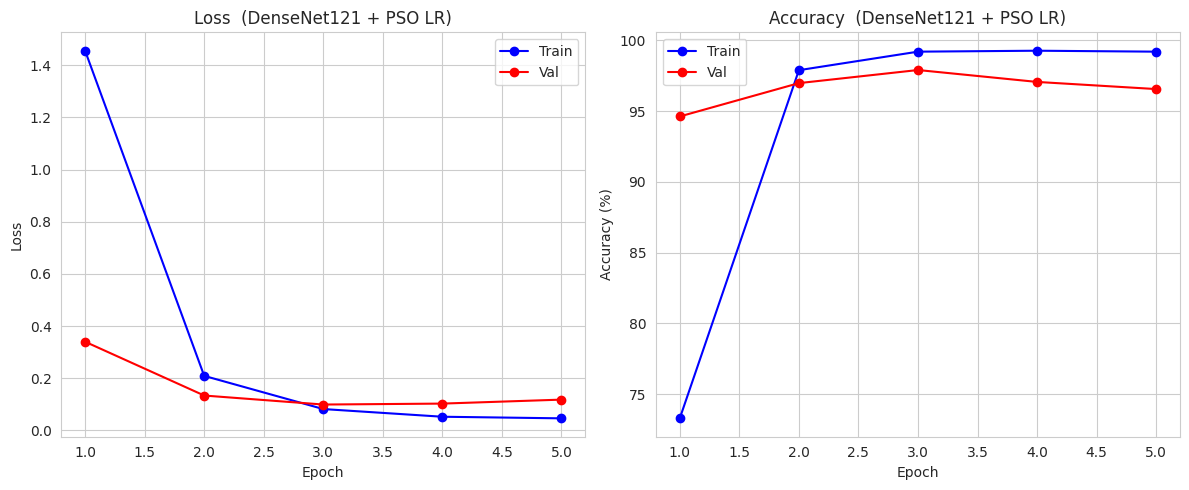

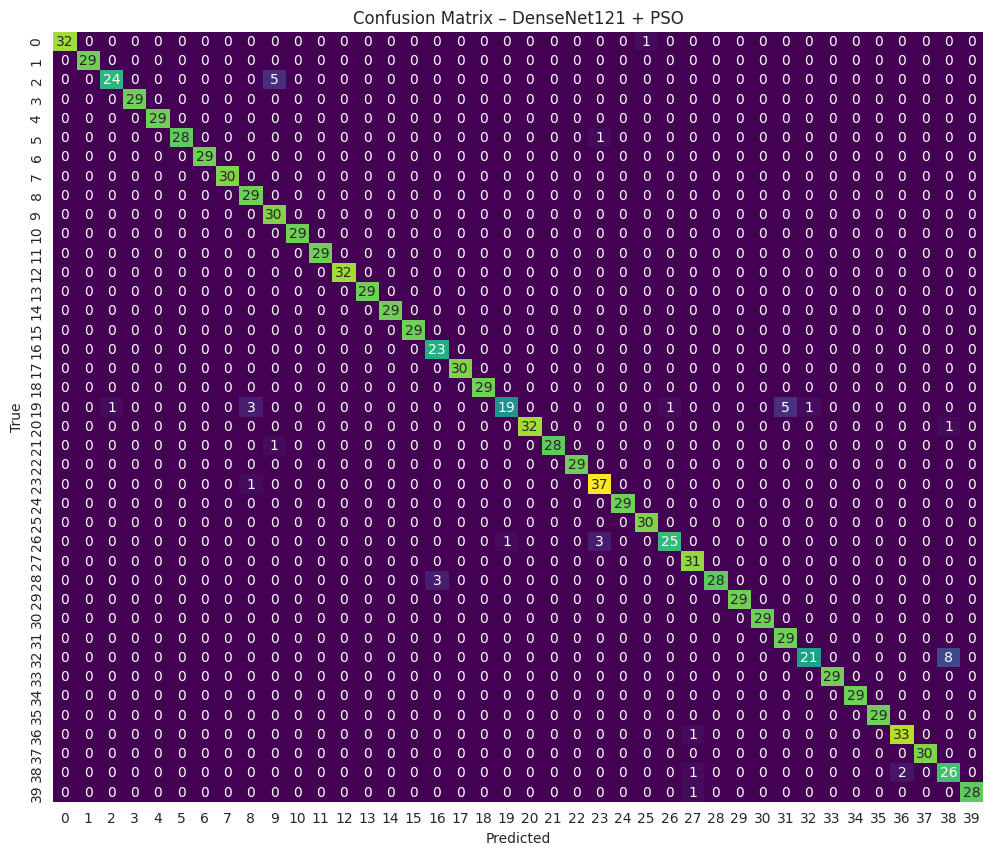


Classification Report – DenseNet121 + PSO
               precision    recall  f1-score   support

     Aloevera       1.00      0.97      0.98        33
         Amla       1.00      1.00      1.00        29
 Amruta_Balli       0.96      0.83      0.89        29
        Arali       1.00      1.00      1.00        29
       Ashoka       1.00      1.00      1.00        29
  Ashwagandha       1.00      0.97      0.98        29
      Avacado       1.00      1.00      1.00        29
       Bamboo       1.00      1.00      1.00        30
       Basale       0.88      1.00      0.94        29
        Betel       0.83      1.00      0.91        30
    Betel_Nut       1.00      1.00      1.00        29
       Brahmi       1.00      1.00      1.00        29
       Castor       1.00      1.00      1.00        32
   Curry_Leaf       1.00      1.00      1.00        29
   Doddapatre       1.00      1.00      1.00        29
         Ekka       1.00      1.00      1.00        29
       Ganike       0

In [22]:
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import pyswarms as ps

print("Using Medicinal plant dataset (40 classes)")
df_to_use = df

all_labels = sorted(df_to_use['label'].unique())
label_to_idx = {label: idx for idx, label in enumerate(all_labels)}
num_classes = len(all_labels)
print(f"Number of classes: {num_classes}")

class PlantDataset(Dataset):
    def __init__(self, df, transform=None, label_to_idx=None):
        self.df = df
        self.transform = transform
        self.label_to_idx = label_to_idx
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        image = Image.open(img_path).convert('RGB')
        label = self.label_to_idx[self.df.iloc[idx]['label']]
        if self.transform:
            image = self.transform(image)
        return image, label

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_df, val_df = train_test_split(df_to_use, test_size=0.2, stratify=df_to_use['label'], random_state=42)
max_samples = train_df['label'].value_counts().max()
balanced_train_df = train_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(n=max_samples, replace=True, random_state=42)
).reset_index(drop=True)

train_dataset = PlantDataset(balanced_train_df, transform_train, label_to_idx)
val_dataset   = PlantDataset(val_df, transform_val, label_to_idx)

train_loader = DataLoader(train_dataset, batch_size=24, shuffle=True,  num_workers=2, pin_memory=True)   # ↓ batch size a bit smaller
val_loader   = DataLoader(val_dataset,   batch_size=24, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def create_densenet_model(num_classes):
    model = models.densenet121(pretrained=True)
    num_features = model.classifier.in_features
    model.classifier = nn.Linear(num_features, num_classes)
    return model.to(device)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5, use_tqdm=True):
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = total = 0
        
        if use_tqdm:
            loader_iter = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', unit='batch')
        else:
            loader_iter = train_loader
        
        for inputs, labels in loader_iter:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            if use_tqdm:
                loader_iter.set_postfix({'loss': f'{running_loss/total:.4f}', 'acc': f'{100.*correct/total:.2f}%'})
        
        train_loss = running_loss / total
        train_acc  = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        model.eval()
        val_loss = 0.0
        correct = total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        val_loss /= total
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f'Epoch {epoch+1:2d}   Train Loss {train_loss:.4f} | Acc {train_acc:5.2f}%   |   Val Loss {val_loss:.4f} | Acc {val_acc:5.2f}%')
    
    return train_losses, val_losses, train_accs, val_accs

def plot_training(train_losses, val_losses, train_accs, val_accs, title=""):
    epochs = range(1, len(train_losses)+1)
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, 'b-o', label='Train')
    plt.plot(epochs, val_losses,   'r-o', label='Val')
    plt.title(f'Loss  {title}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(epochs, train_accs, 'b-o', label='Train')
    plt.plot(epochs, val_accs,   'r-o', label='Val')
    plt.title(f'Accuracy  {title}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

def get_predictions(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, p = torch.max(outputs, 1)
            preds.extend(p.cpu().numpy())
            trues.extend(labels.numpy())
    return np.array(trues), np.array(preds)

print("\n" + "═"*70)
print("Training Standard DenseNet121   (with tqdm progress)")
model_std = create_densenet_model(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_std.parameters(), lr=0.0005)   

losses_t, losses_v, accs_t, accs_v = train_model(
    model_std, train_loader, val_loader, criterion, optimizer,
    num_epochs=5, use_tqdm=True
)

plot_training(losses_t, losses_v, accs_t, accs_v, "(DenseNet121 Standard)")

trues, preds = get_predictions(model_std, val_loader)
cm = confusion_matrix(trues, preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', cbar=False)
plt.title('Confusion Matrix – DenseNet121 Standard')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("\nClassification Report – DenseNet121 Standard")
print(classification_report(trues, preds, target_names=all_labels, zero_division=0))

print("\n" + "═"*70)
print("PSO → searching best learning rate for DenseNet121   (quiet mode)")

def objective_function(lrs, num_epochs=3):
    costs = []
    for lr in lrs:
        model_temp = create_densenet_model(num_classes)
        crit = nn.CrossEntropyLoss()
        opt  = optim.Adam(model_temp.parameters(), lr=lr[0])
        
        _, _, _, val_acc_history = train_model(
            model_temp, train_loader, val_loader, crit, opt,
            num_epochs=num_epochs, use_tqdm=False
        )
        
        costs.append( -val_acc_history[-1] )
        del model_temp
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    return np.array(costs)

options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
bounds = (np.array([5e-5]), np.array([5e-3]))  
optimizer_pso = ps.single.GlobalBestPSO(n_particles=4, dimensions=1, options=options, bounds=bounds)

cost, pos = optimizer_pso.optimize(objective_function, iters=3)
best_lr = pos[0]
print(f"\nBest learning rate found by PSO: {best_lr:.7f}")

print("\nFinal training DenseNet121 with PSO-best LR   (with tqdm)")
model_pso = create_densenet_model(num_classes)
optimizer = optim.Adam(model_pso.parameters(), lr=best_lr)

losses_tp, losses_vp, accs_tp, accs_vp = train_model(
    model_pso, train_loader, val_loader, criterion, optimizer,
    num_epochs=5, use_tqdm=True
)

plot_training(losses_tp, losses_vp, accs_tp, accs_vp, "(DenseNet121 + PSO LR)")

trues_p, preds_p = get_predictions(model_pso, val_loader)
cm_p = confusion_matrix(trues_p, preds_p)

plt.figure(figsize=(12,10))
sns.heatmap(cm_p, annot=True, fmt='d', cmap='viridis', cbar=False)
plt.title('Confusion Matrix – DenseNet121 + PSO')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("\nClassification Report – DenseNet121 + PSO")
print(classification_report(trues_p, preds_p, target_names=all_labels, zero_division=0))

print("\nDone. Compare DenseNet121 standard vs PSO-tuned versions.")

In [23]:
def predict_image(
    image_path,
    model,
    transform,
    label_map,
    device,
    top_k=3
):
    """
    Predict class for a single image.

    Args:
        image_path (str): Path to image
        model (torch.nn.Module): trained model
        transform (torchvision.transforms): validation transform
        label_map (dict): idx -> class label
        device (torch.device)
        top_k (int): number of top predictions

    Returns:
        list of tuples (class_name, confidence)
    """
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)

        top_probs, top_idxs = probs.topk(top_k, dim=1)

    results = []
    for p, idx in zip(top_probs[0], top_idxs[0]):
        class_name = label_map[idx.item()]
        confidence = p.item() * 100
        results.append((class_name, confidence))

    return results

In [24]:
idx_to_label = {v: k for k, v in label_to_idx.items()}

In [50]:
image_path = "/kaggle/input/datasets/aryashah2k/indian-medicinal-leaves-dataset/Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Brahmi/394.jpg"   # 🔁 change path

predictions = predict_image(
    image_path=image_path,
    model=model_std,
    transform=transform_val,
    label_map=idx_to_label,
    device=device,
    top_k=3
)

print("\nPrediction (Standard DenseNet121):")
for cls, conf in predictions:
    print(f"{cls:<25}  {conf:.2f}%")


Prediction (Standard DenseNet121):
Brahmi                     99.81%
Amruta_Balli               0.09%
Mango                      0.05%


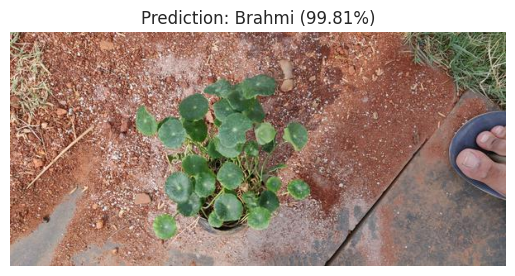

In [51]:
import matplotlib.pyplot as plt

img = Image.open(image_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predictions[0][0]} ({predictions[0][1]:.2f}%)")
plt.show()

In [35]:
MODEL_PATH = "densenet121_pso_medicinal_plants.pth"

torch.save({
    "model_state_dict": model_pso.state_dict(),
    "num_classes": num_classes,
    "label_to_idx": label_to_idx
}, MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")

Model saved to densenet121_pso_medicinal_plants.pth
